In [1]:
import pandas as pd

df = pd.read_csv("bank-full.csv", sep=';')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [2]:
df.isnull().sum()
df.shape

(45211, 17)

In [3]:
total_users = len(df)

leads = df[df['duration'] > 100]

customers = df[df['y'] == 'yes']

In [4]:
visitor_to_lead = len(leads) / total_users
lead_to_customer = len(customers) / len(leads)
overall_conversion = len(customers) / total_users

visitor_to_lead, lead_to_customer, overall_conversion

(0.7592842449846277, 0.15407247727802378, 0.11698480458295547)

In [6]:
df['y'] = df['y'].map({'yes':1, 'no':0})

In [7]:
df['y'].dtype

dtype('int64')

In [8]:
df.groupby('job')['y'].mean().sort_values(ascending=False)

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64

In [9]:
df.groupby('month')['y'].mean().sort_values(ascending=False)

month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64

In [10]:
df.groupby('poutcome')['y'].mean().sort_values(ascending=False)

poutcome
success    0.647253
other      0.166848
failure    0.126097
unknown    0.091615
Name: y, dtype: float64

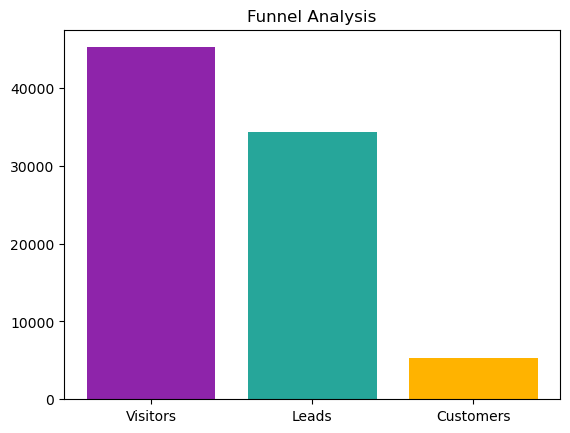

In [13]:
colors = ['#8E24AA', '#26A69A', '#FFB300']

plt.figure()
plt.bar(['Visitors','Leads','Customers'],
        [total_users, len(leads), len(customers)],
        color=colors)
plt.title("Funnel Analysis")
plt.show()

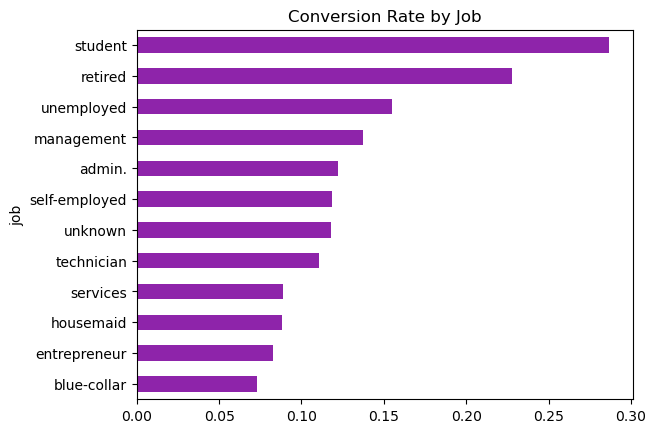

In [14]:
df.groupby('job')['y'].mean().sort_values().plot(
    kind='barh',
    color='#8E24AA'
)
plt.title("Conversion Rate by Job")
plt.show()

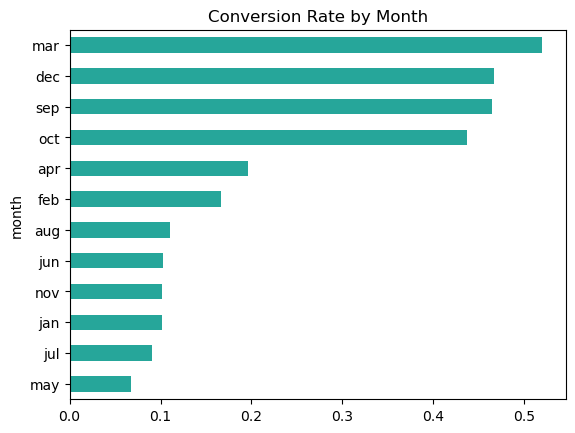

In [15]:
df.groupby('month')['y'].mean().sort_values().plot(
    kind='barh',
    color='#26A69A'
)
plt.title("Conversion Rate by Month")
plt.show()

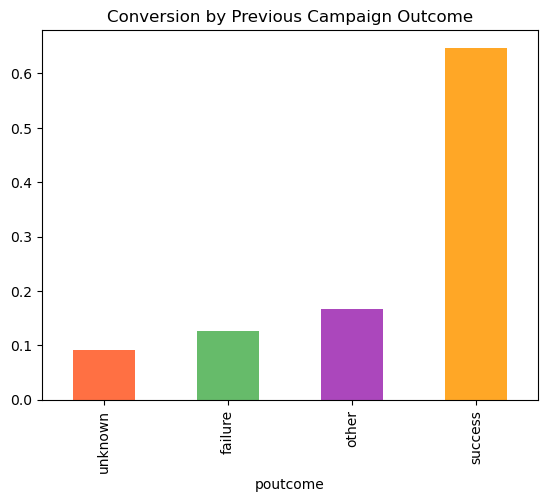

In [16]:
df.groupby('poutcome')['y'].mean().sort_values().plot(
    kind='bar',
    color=['#FF7043','#66BB6A','#AB47BC','#FFA726']
)
plt.title("Conversion by Previous Campaign Outcome")
plt.show()

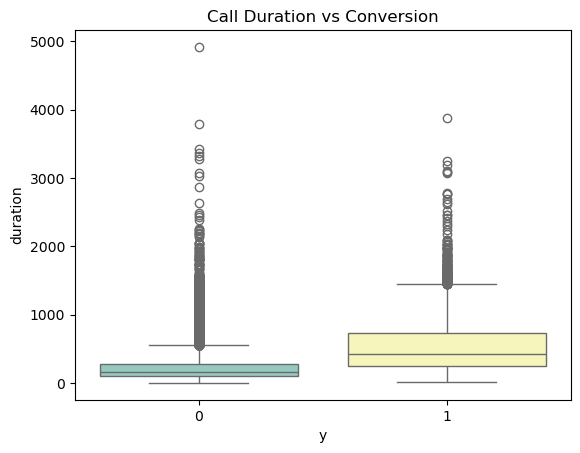

In [19]:
import seaborn as sns

sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set3', legend=False)
plt.title("Call Duration vs Conversion")
plt.show()